# 01 — Exploratory Data Analysis

This notebook runs all EDA analyses for both the **SKU-110K (filtered subset)** and **Synthetic Overlapping Shapes** datasets.

**Outputs** → `reports/figures/`

| # | Analysis | SKU-110K Output | Synthetic Output |
|---|----------|-----------------|------------------|
| 1 | Object count distribution | `object_count_distribution.png` | `synth_object_count_distribution.png` |
| 2 | Object size distribution | `object_size_distribution.png` | `synth_object_size_distribution.png` |
| 3 | Occlusion analysis | `occlusion_analysis.png` | `synth_occlusion_analysis.png` |
| 4 | Easy vs hard samples | `sample_easy_vs_hard.png` | `synth_sample_easy_vs_hard.png` |
| 5 | Summary statistics | `summary_statistics.csv/.tex` | `synth_summary_statistics.csv/.tex` |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.eda import (
    run_eda,
    _load_all_splits,
    _load_synthetic_annotations,
    _annotations_to_dataframe,
    _coco_to_dataframe,
    plot_object_count_distribution,
    plot_object_size_distribution,
    plot_occlusion_analysis,
    plot_easy_vs_hard_samples,
    compute_summary_statistics,
)
from src.utils.visualization import setup_style
setup_style()

%matplotlib inline
print('Imports OK')

Imports OK


---
## 1. Load Data

In [2]:
# ---- Synthetic dataset ----
coco = _load_synthetic_annotations()
if coco:
    synth_df = _coco_to_dataframe(coco)
    print(f'Synthetic: {len(synth_df):,} annotations, {synth_df["image_name"].nunique():,} images')
else:
    synth_df = None
    print('⚠ Synthetic data not found. Run: python -m src.synthetic_generator')

Synthetic: 13,002 annotations, 500 images


In [3]:
# ---- SKU-110K splits ----
splits = _load_all_splits()
all_entries = []
for entries in splits.values():
    all_entries.extend(entries)

if all_entries:
    sku_df = _annotations_to_dataframe(all_entries)
    print(f'SKU-110K: {len(sku_df):,} annotations, {sku_df["image_name"].nunique():,} images')
else:
    sku_df = None
    print('⚠ SKU-110K split data not found. Run: python -m src.data_loader')

⚠ SKU-110K split data not found. Run: python -m src.data_loader


---
## 2. Object Count Distribution

[viz] Saved figure → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_object_count_distribution.png


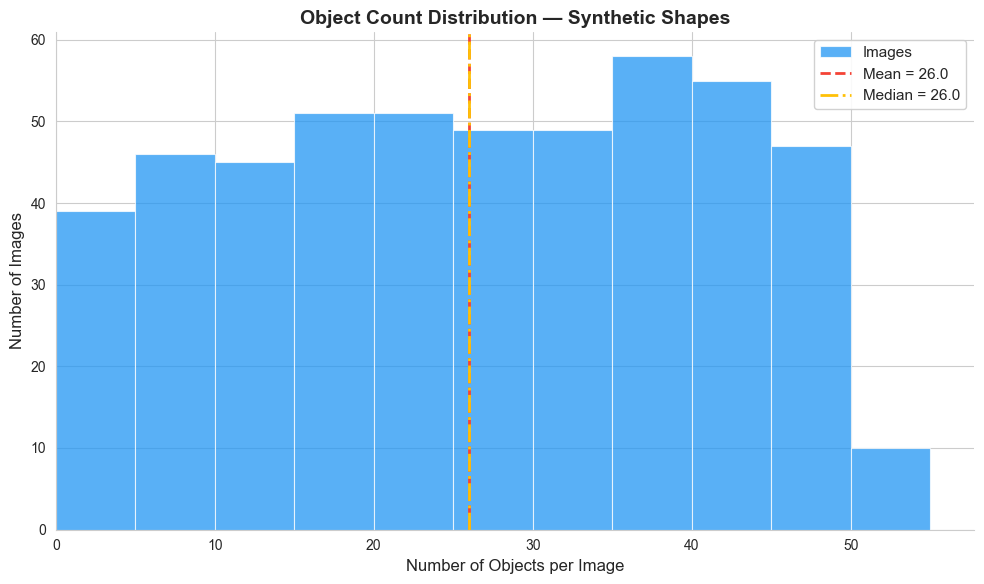

In [4]:
if synth_df is not None:
    fig = plot_object_count_distribution(synth_df, dataset='synthetic')
    plt.show()

In [5]:
if sku_df is not None:
    fig = plot_object_count_distribution(sku_df, dataset='sku110k')
    plt.show()

---
## 3. Object Size Distribution

/Users/samarthshekhar3541/Desktop/Bell_Labs/src/eda.py:295: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/Users/samarthshekhar3541/Desktop/Bell_Labs/src/eda.py:295: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/samarthshekhar3541/Desktop/Bell_Labs/src/utils/visualization.py:118: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=300, bbox_inches="tight")
/Users/samarthshekhar3541/Desktop/Bell_Labs/src/utils/visualization.py:118: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=300, bbox_inches="tight")
/opt/homebrew/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 

[viz] Saved figure → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_object_size_distribution.png


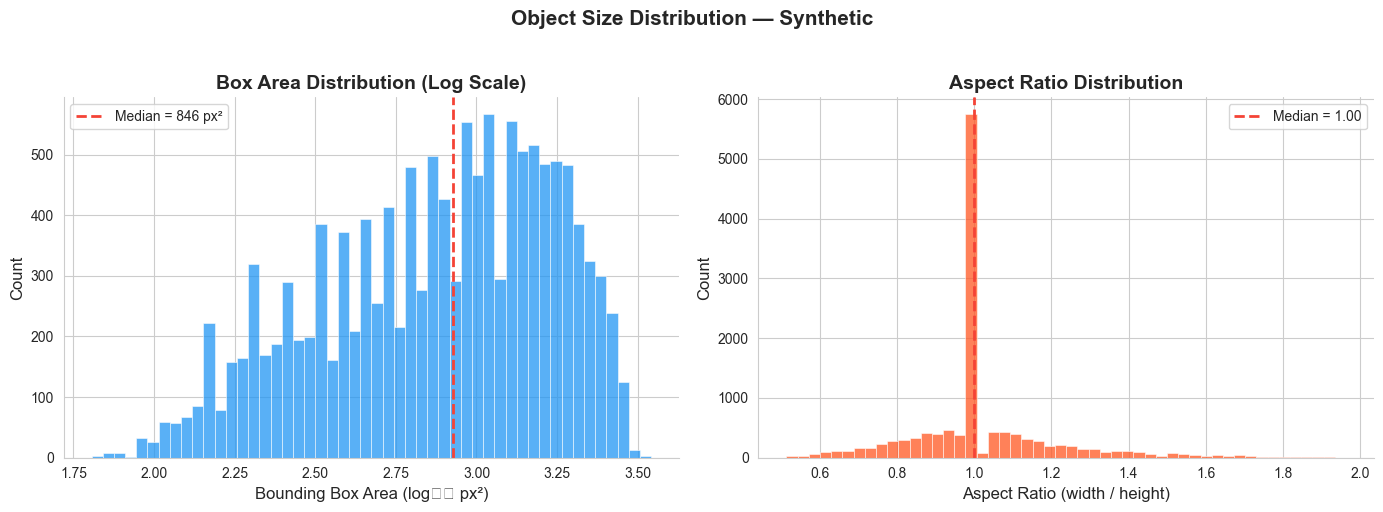

In [6]:
if synth_df is not None:
    fig = plot_object_size_distribution(synth_df, dataset='synthetic')
    plt.show()

In [7]:
if sku_df is not None:
    fig = plot_object_size_distribution(sku_df, dataset='sku110k')
    plt.show()

---
## 4. Occlusion Analysis

[viz] Saved figure → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_occlusion_analysis.png


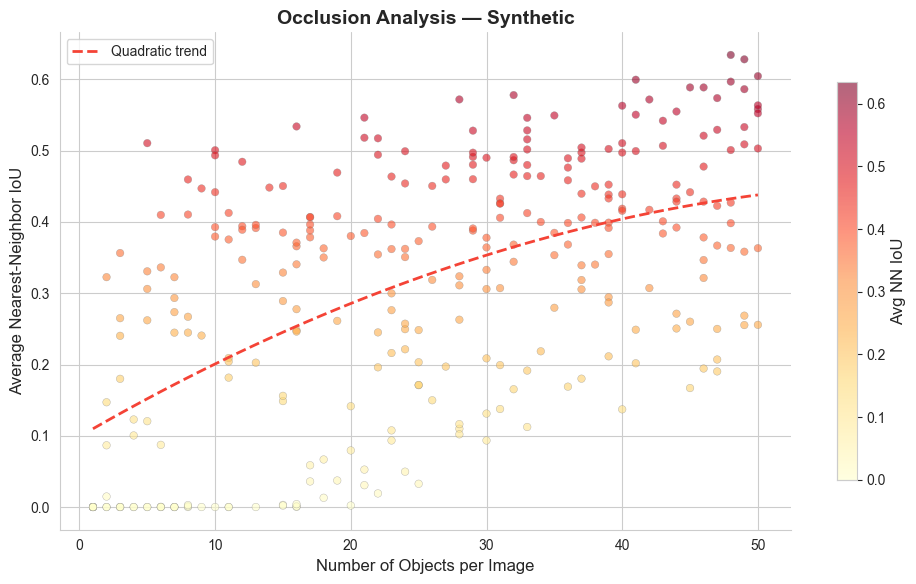

In [8]:
if synth_df is not None:
    fig = plot_occlusion_analysis(synth_df, dataset='synthetic', max_images=300)
    plt.show()

In [9]:
if sku_df is not None:
    fig = plot_occlusion_analysis(sku_df, dataset='sku110k', max_images=300)
    plt.show()

---
## 5. Sample Visualizations (Easy vs Hard)

[viz] Saved figure → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_sample_easy_vs_hard.png


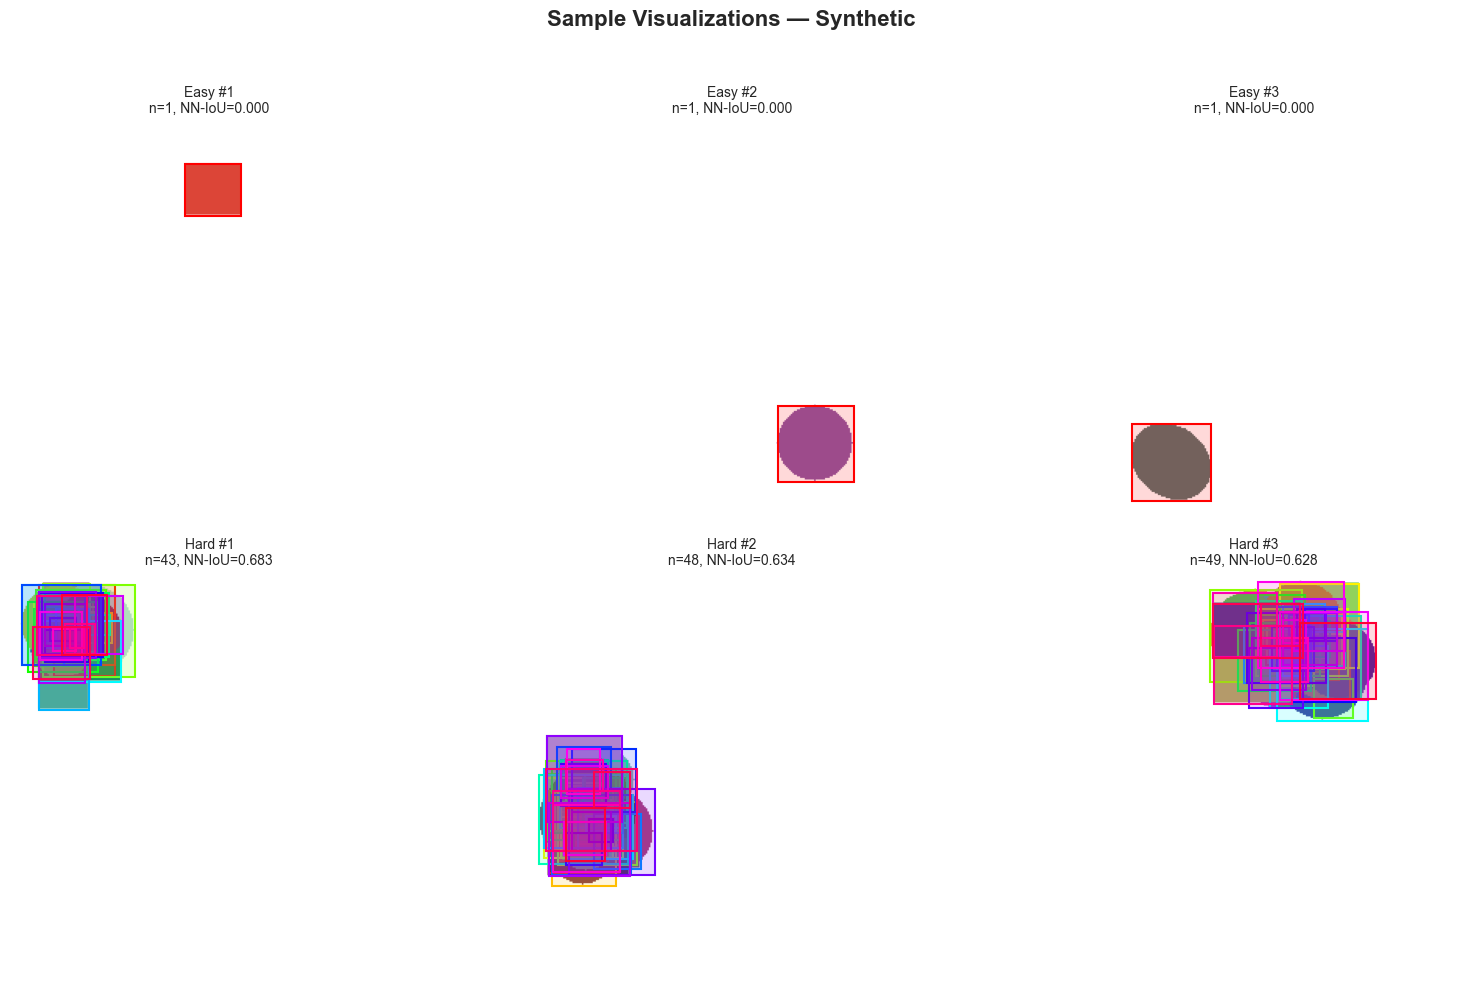

In [10]:
if synth_df is not None:
    fig = plot_easy_vs_hard_samples(synth_df, dataset='synthetic')
    plt.show()

In [11]:
if sku_df is not None:
    fig = plot_easy_vs_hard_samples(sku_df, dataset='sku110k')
    plt.show()

---
## 6. Summary Statistics

In [12]:
if synth_df is not None:
    synth_summary = compute_summary_statistics(synth_df, dataset='synthetic')
    display(synth_summary)

[eda] Saved summary CSV → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_summary_statistics.csv
[eda] Saved summary LaTeX → /Users/samarthshekhar3541/Desktop/Bell_Labs/reports/figures/synth_summary_statistics.tex


,split,num_images,mean_objects,median_objects,max_objects,mean_box_area,mean_nn_iou
0,all,500,26.0,26.0,50,999.8,0.3004


In [13]:
if sku_df is not None:
    sku_summary = compute_summary_statistics(sku_df, splits=splits, dataset='sku110k')
    display(sku_summary)

---
## Done

All figures saved to `reports/figures/`.
Summary statistics saved as `.csv` and `.tex` files.